In [2]:
from os import listdir, makedirs
from os.path import isfile, isdir, join

import numpy as np
import pandas as pd

flare_file_path = './output/joined_flares.csv'
aia_fl_dir_path = '../datain/'
goes_fl_dir_path = '../datain/'


In [3]:
def get_aia_flare_dataframe(file_path):
    """Reads the flare dataframe given in flare file path, downloaded using our script"""
    df = pd.read_csv(file_path, delimiter='\t', parse_dates=True)
    df['end_time'] = fix_timestamps(df['end_time'], format='%Y-%m-%dT%H:%M:%S')
    df['start_time'] = fix_timestamps(df['start_time'], format='%Y-%m-%dT%H:%M:%S')
    df['peak_time'] = fix_timestamps(df['peak_time'], format='%Y-%m-%dT%H:%M:%S')
    return df

def get_goes_flare_dataframe(file_path):
    """Reads the flare dataframe given in flare file path, downloaded using our script"""
    df = pd.read_csv(file_path, delimiter='\t', parse_dates=True)
    df['end_time'] = fix_timestamps(df['end_time'], format='%Y-%m-%d %H:%M:%S')
    df['start_time'] = fix_timestamps(df['start_time'], format='%Y-%m-%d %H:%M:%S')
    df['peak_time'] = fix_timestamps(df['peak_time'], format='%Y-%m-%d %H:%M:%S')
    return df


def fix_timestamps(ds, format=None):
    if format is None:
        ds_fixed = pd.to_datetime(ds, format="%Y%m%d_%H%M%S")
    else:
        ds_fixed = pd.to_datetime(ds, format=format)
    return ds_fixed

def remove_duplicates_from_goes_flares(goes_df):
    # remove all totally duplicated rows from goes df
    duplicates = goes_df.duplicated(subset=['start_time', 'end_time', 'peak_time', 'noaa_active_region', 'goes_class', 'goes_location'], keep='first')
    duplicated = goes_df[duplicates]
    goes_df = goes_df[~duplicates]
    return goes_df, duplicated


def remove_duplicates_from_aia_flares(aia_df):
    duplicates = aia_df.duplicated(subset=['start_time', 'end_time', 'peak_time','noaa_active_region', 'goes_class', 'goes_location'], keep='first')
    duplicated = aia_df[duplicates]
    aia_df = aia_df[~duplicates]
    return aia_df, duplicated


In [128]:
all_files = [f for f in listdir(aia_fl_dir_path) if isfile(join(aia_fl_dir_path, f))]
aia_files = [f for f in all_files if f.startswith('aiaFlares')]

aia_data_list = []
total_aia = 0
for f in aia_files:
    
    temp_aia = get_aia_flare_dataframe(join(aia_fl_dir_path, f))
    aia_data_list.append(temp_aia)
    print join(aia_fl_dir_path, f),
    print temp_aia.shape[0]
    total_aia += temp_aia.shape[0]
    
all_aia_flares = pd.concat(aia_data_list, axis=0)
if all_aia_flares.shape[0] != total_aia: print 'There is a problem with joining yearly flare files'
# print total_aia

# all_aia= remove_duplicates_from_aia_flares(all_aia_flares)
all_aia, dupl_aia = remove_duplicates_from_aia_flares(all_aia_flares)
print 'Removed {0} AIA flares'.format(dupl_aia.shape[0])
print 'Writing {0} AIA flares from 2010 to 2018'.format(all_aia.shape[0])
all_aia.to_csv('../datain/aia_flares_all.csv', sep='\t', index=False)

../datain/aiaFlares_2012.csv 1654
../datain/aiaFlares_2018.csv 435
../datain/aiaFlares_2013.csv 1388
../datain/aiaFlares_2015.csv 2018
../datain/aiaFlares_2017.csv 1117
../datain/aiaFlares_2010.csv 814
../datain/aiaFlares_2016.csv 1332
../datain/aiaFlares_2011.csv 2421
../datain/aiaFlares_2014.csv 2252
../datain/aiaFlares_Jun_2017.csv 103
Removed 409 AIA flares
Writing 13125 AIA flares from 2010 to 2018


In [145]:
all_files = [f for f in listdir(goes_fl_dir_path) if isfile(join(goes_fl_dir_path, f))]
goes_files = [f for f in all_files if f.startswith('goesFlares')]

goes_data_list = []
total_goes = 0
for f in goes_files:
    
    temp_goes = get_goes_flare_dataframe(join(goes_fl_dir_path, f))
    goes_data_list.append(temp_goes)
    print join(goes_fl_dir_path, f),
    print temp_goes.shape[0]
    total_goes += temp_goes.shape[0]
    
all_goes_flares = pd.concat(goes_data_list, axis=0)
if all_goes_flares.shape[0] != total_goes: print 'There is a problem with joining yearly flare files'
print total_goes

all_goes, dupl_goes = remove_duplicates_from_goes_flares(all_goes_flares)
print 'Removed {0} GOES flares'.format(dupl_goes.shape[0])
print 'Writing {0} GOES flares from 2010 to 2018'.format(all_goes.shape[0])
# all_goes.to_csv('../datain/goes_flares_all.csv', sep='\t', index=False)

../datain/goesFlares_2015.csv 2051
../datain/goesFlares_2017.csv 1141
../datain/goesFlares_2014.csv 2260
../datain/goesFlares_2013.csv 2062
../datain/goesFlares_2018.csv 306
../datain/goesFlares_2011.csv 2230
../datain/goesFlares_2010.csv 907
../datain/goesFlares_2016.csv 1267
../datain/goesFlares_2012.csv 2189
14413
Removed 41 GOES flares
Writing 14372 GOES flares from 2010 to 2018


In [3]:
def get_aia_flare_dataframe(file_path):
    """Reads the flare dataframe given in flare file path, downloaded using our script"""
    df = pd.read_csv(file_path, delimiter='\t', parse_dates=True)
    df['end_time'] = fix_timestamps(df['end_time'], format='%Y-%m-%dT%H:%M:%S')
    df['start_time'] = fix_timestamps(df['start_time'], format='%Y-%m-%dT%H:%M:%S')
    df['peak_time'] = fix_timestamps(df['peak_time'], format='%Y-%m-%dT%H:%M:%S')
    return df

def get_goes_flare_dataframe(file_path):
    """Reads the flare dataframe given in flare file path, downloaded using our script"""
    df = pd.read_csv(file_path, delimiter='\t', parse_dates=True)
    df['end_time'] = fix_timestamps(df['end_time'], format='%Y-%m-%d %H:%M:%S')
    df['start_time'] = fix_timestamps(df['start_time'], format='%Y-%m-%d %H:%M:%S')
    df['peak_time'] = fix_timestamps(df['peak_time'], format='%Y-%m-%d %H:%M:%S')
    return df


def fix_timestamps(ds, format=None):
    if format is None:
        ds_fixed = pd.to_datetime(ds, format="%Y%m%d_%H%M%S")
    else:
        ds_fixed = pd.to_datetime(ds, format=format)
    return ds_fixed

def remove_duplicates_from_goes_flares(goes_df):
    # remove all totally duplicated rows from goes df
    duplicates = goes_df.duplicated(subset=['start_time', 'end_time', 'peak_time', 'noaa_active_region', 'goes_class', 'goes_location'], keep='first')
    duplicated = goes_df[duplicates]
    goes_df = goes_df[~duplicates]
    return goes_df, duplicated


def remove_duplicates_from_aia_flares(aia_df):
    duplicates = aia_df.duplicated(subset=['start_time', 'end_time', 'peak_time','noaa_active_region', 'goes_class', 'goes_location'], keep='first')
    duplicated = aia_df[duplicates]
    aia_df = aia_df[~duplicates]
    return aia_df, duplicated


/home/baydin2/anaconda2/lib/python2.7/site-packages/seaborn/categorical.py:1468: FutureWarning: remove_na is deprecated and is a private function. Do not use.
  stat_data = remove_na(group_data[hue_mask])


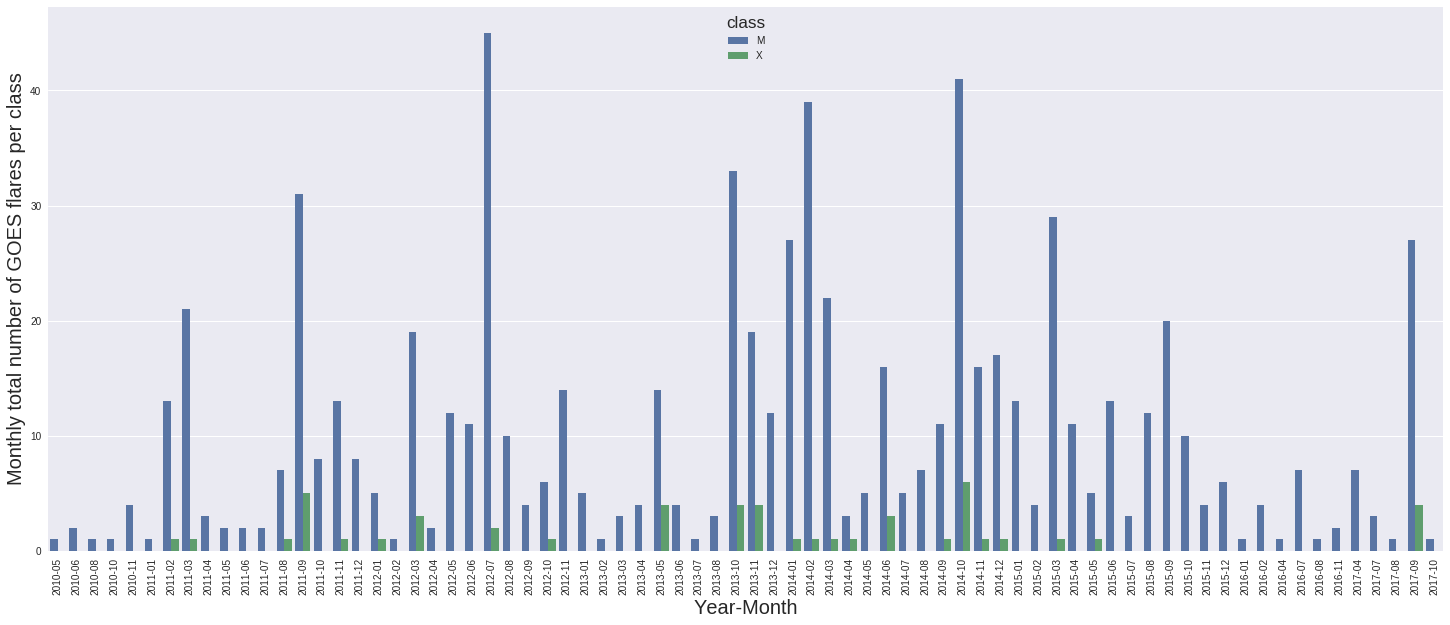

In [4]:
%matplotlib inline

import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
sns.set(rc={'figure.figsize':(25,10), "font.size":26,"axes.titlesize":26,"axes.labelsize":20})



# datax = all_goes[['event_date', 'peak_time']].groupby('event_date').count()
# sns.countplot(  )
# titanic = sns.load_dataset("titanic")
# titanic
# ax = sns.countplot(x="class", data=titanic)
# 
all_goes = get_goes_flare_dataframe('../datain/goes_flares_all.csv')
_plotter = all_goes.copy()

_plotter['Month'] = _plotter['event_date'].str[5:7] 
_plotter['Year'] = all_goes['event_date'].str[:4] 
_plotter['Year-Month'] = _plotter[['Year','Month']].apply(lambda x: '-'.join(x), axis=1)
_plotter.sort_values(['Year-Month'])
_plotter_2011 = _plotter[ _plotter['Year'] >= '2010' ]
_plotter_2011['class'] = _plotter_2011['goes_class'].str[:1] 
_plotter_2011 = _plotter_2011[_plotter_2011['class'] > 'C']

sns.countplot(x = 'Year-Month', hue='class', data=_plotter_2011)
plt.xticks(rotation=90)
plt.ylabel("Monthly total number of GOES flares per class")
# plt.yscale('log')
plt.savefig('goes_fl_counts.pdf',  bbox_inches='tight')



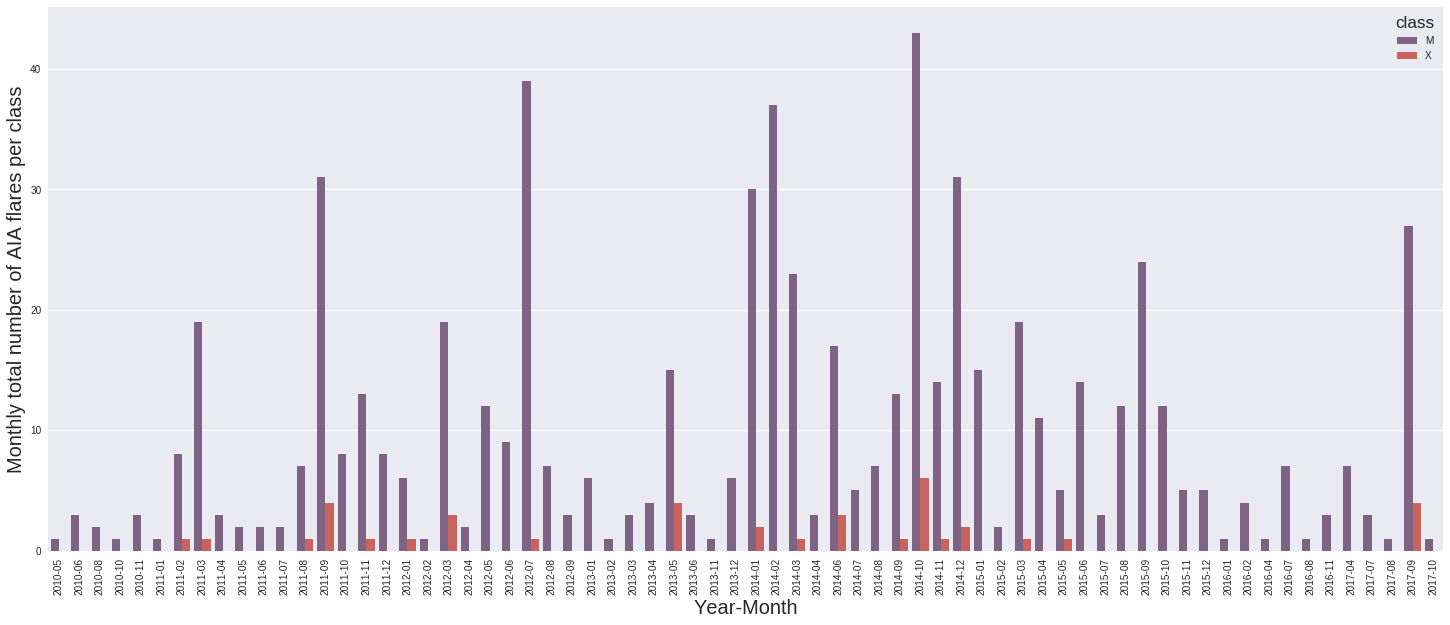

In [5]:
%matplotlib inline

import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(rc={'figure.figsize':(25,10), "font.size":26,"axes.titlesize":26,"axes.labelsize":20})

# datax = all_goes[['event_date', 'peak_time']].groupby('event_date').count()
# sns.countplot(  )
# titanic = sns.load_dataset("titanic")
# titanic
# ax = sns.countplot(x="class", data=titanic)
# 
all_aia = get_aia_flare_dataframe('../datain/aia_flares_all.csv')

_plotter = all_aia.copy()

_plotter['Month'] = _plotter['event_date'].str[5:7] 
_plotter['Year'] = all_aia['event_date'].str[:4] 
_plotter['Year-Month'] = _plotter[['Year','Month']].apply(lambda x: '-'.join(x), axis=1)
_plotter.sort_values(['Year-Month'])
_plotter_2011 = _plotter[ _plotter['Year'] >= '2010' ]
_plotter_2011['class'] = _plotter_2011['goes_class'].str[:1] 
_plotter_2011 = _plotter_2011[_plotter_2011['class'] > 'C']

# current_palette_4 = sns.color_palette("jet", 4)
colors = ["dusty purple", "pale red"]

sns.set_palette(sns.xkcd_palette(colors))
sns.countplot(x = 'Year-Month', hue='class', data=_plotter_2011)
plt.xticks(rotation=90)
plt.ylabel("Monthly total number of AIA flares per class")
# plt.yscale('log')
plt.savefig('aia_fl_counts.pdf',  bbox_inches='tight')


14372
9375
3413


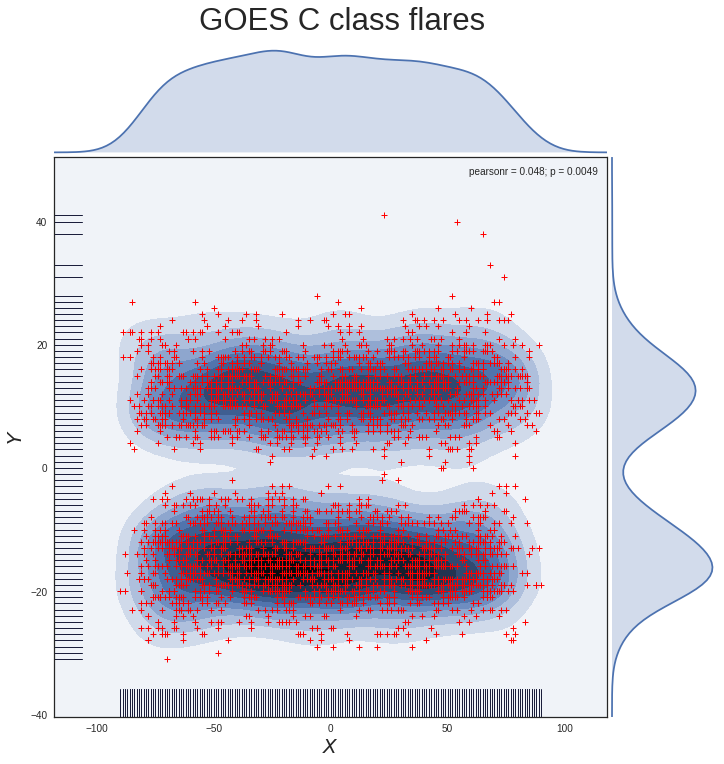

In [243]:
%matplotlib inline

import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(rc={'figure.figsize':(16,12), "font.size":26,"axes.titlesize":26,"axes.labelsize":20})

# datax = all_goes[['event_date', 'peak_time']].groupby('event_date').count()
# sns.countplot(  )
# titanic = sns.load_dataset("titanic")
# titanic
# ax = sns.countplot(x="class", data=titanic)
# 
print all_goes.shape[0]
_plotter = all_goes.copy()

_plotter_2011 = _plotter#[ _plotter['Year'] == '2011' ]
_plotter_2011['class'] = _plotter_2011['goes_class'].str[:1] 

print _plotter_2011[_plotter_2011['goes_location'] == '(0, 0)'].shape[0]

_plotter_2011 = _plotter_2011[_plotter_2011['class'] == 'C']
_plotter_2011 = _plotter_2011[_plotter_2011['goes_location'] != '(0, 0)']


_plotter_2011['x_loc'] = _plotter_2011['goes_location'].str.strip(')').str.strip('(').str.split(', ').apply(lambda x: x[0])
_plotter_2011['y_loc'] = _plotter_2011['goes_location'].str.strip(')').str.strip('(').str.split(', ').apply(lambda x: x[1])


x_loc = pd.to_numeric(_plotter_2011['x_loc'])
y_loc = pd.to_numeric(_plotter_2011['y_loc'])
_plotter_2011['x_loc'] = x_loc
_plotter_2011['y_loc'] = y_loc
print _plotter_2011.shape[0]

with sns.axes_style("white"):
#     sns.jointplot(x='x_loc', y='y_loc', data=_plotter_2011, kind='kde', color="k");
    g = sns.jointplot(x="x_loc", y="y_loc", data=_plotter_2011, space=0, kind="kde")
    current_palette_4 = sns.color_palette("cubehelix", 7)
    sns.set_palette(current_palette_4)
    
    g.plot_joint(plt.scatter, c="r", s=30, linewidth=1, marker="+")
    g.ax_joint.collections[0].set_alpha(1)
    g.set_axis_labels("$X$", "$Y$");
    g.fig.set_figwidth(12)
    g.fig.set_figheight(12)
    sns.rugplot(x_loc, ax=g.fig.axes[0])
    sns.rugplot(y_loc, vertical=True, ax=g.fig.axes[0]);
    mytitle = "GOES C class flares" 
    g.fig.suptitle(mytitle)
    
    g.fig.savefig(mytitle + '.pdf',  bbox_inches='tight', dpi=g.fig.dpi)



/home/baydin2/anaconda2/lib/python2.7/site-packages/ipykernel/__main__.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy
/home/baydin2/anaconda2/lib/python2.7/site-packages/ipykernel/__main__.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy
/home/baydin2/anaconda2/lib/python2.7/site-packages/ipykernel/__main__.py:26: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/

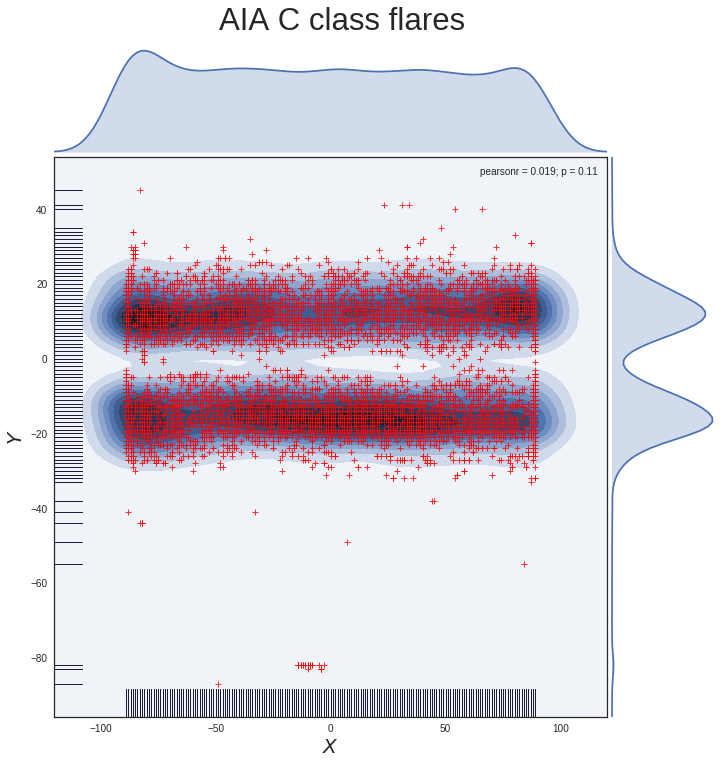

In [173]:
%matplotlib inline

import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(rc={'figure.figsize':(16,12), "font.size":26,"axes.titlesize":26,"axes.labelsize":20})


_plotter = all_aia.copy()
_plotter['Month'] = _plotter['event_date'].str[5:7] 
_plotter['Year'] = all_aia['event_date'].str[:4] 
_plotter['Year-Month'] = _plotter[['Year','Month']].apply(lambda x: '-'.join(x), axis=1)
_plotter.sort_values(['Year-Month'])
_plotter_2011 = _plotter#[ _plotter['Year'] == '2011' ]
_plotter_2011['class'] = _plotter_2011['goes_class'].str[:1] 
_plotter_2011 = _plotter_2011[_plotter_2011['class'] == 'C']

# _plotter_2011 = _plotter_2011[_plotter_2011['goes_location'] != '(0, 0)']
_plotter_2011['x_loc'] = _plotter_2011['goes_location'].str.strip(')').str.strip('POINT(').str.split(' ').apply(lambda x: x[0])
_plotter_2011['y_loc'] = _plotter_2011['goes_location'].str.strip(')').str.strip('POINT(').str.split(' ').apply(lambda x: x[1])

# _plotter_2011[_plotter_2011['y_loc'] < -70]

x_loc = pd.to_numeric(_plotter_2011['x_loc'])
y_loc = pd.to_numeric(_plotter_2011['y_loc'])
_plotter_2011['x_loc'] = x_loc
_plotter_2011['y_loc'] = y_loc

with sns.axes_style("white"):
#     sns.jointplot(x='x_loc', y='y_loc', data=_plotter_2011, kind='kde', color="k");
    g = sns.jointplot(x="x_loc", y="y_loc", data=_plotter_2011, space=0, kind="kde")
    current_palette_4 = sns.color_palette("cubehelix", 7)
    sns.set_palette(current_palette_4)
    
    g.plot_joint(plt.scatter, c="r", alpha=0.8, s=30, linewidth=1, marker="+")
    g.ax_joint.collections[0].set_alpha(1)
    g.set_axis_labels("$X$", "$Y$");
    g.fig.set_figwidth(12)
    g.fig.set_figheight(12)

    sns.rugplot(x_loc, ax=g.fig.axes[0])
    sns.rugplot(y_loc, vertical=True, ax=g.fig.axes[0]);

    mytitle = "AIA C class flares" 
    g.fig.suptitle(mytitle)
    
    g.fig.savefig(mytitle + '.pdf',  bbox_inches='tight', dpi=g.fig.dpi)


/home/baydin2/anaconda2/lib/python2.7/site-packages/ipykernel/__main__.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy
/home/baydin2/anaconda2/lib/python2.7/site-packages/ipykernel/__main__.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy
/home/baydin2/anaconda2/lib/python2.7/site-packages/ipykernel/__main__.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/

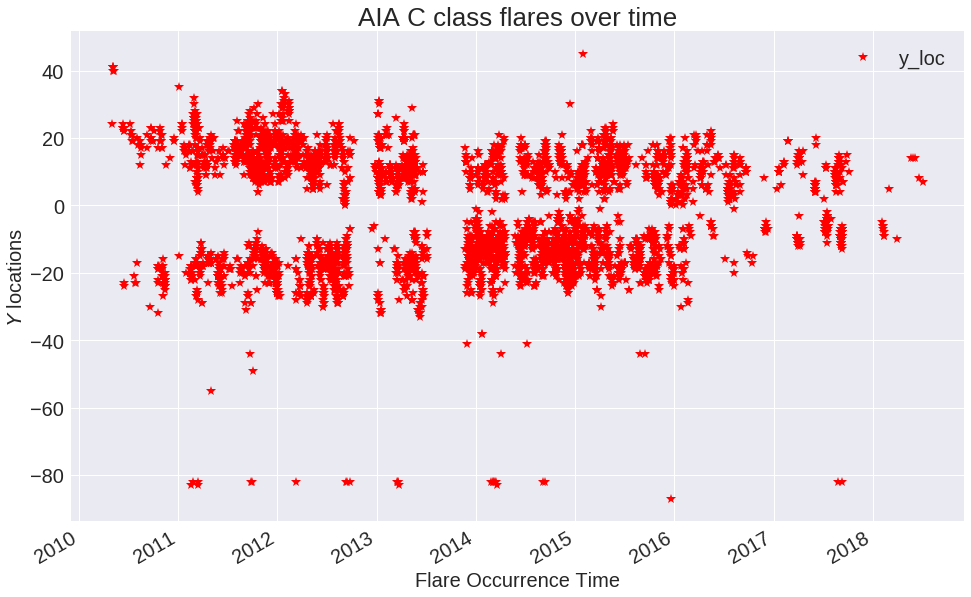

In [197]:
# _plotter_2011.head(500).plot()

_plotter = all_aia.copy()
_plotter['Month'] = _plotter['event_date'].str[5:7] 
_plotter['Year'] = all_aia['event_date'].str[:4] 
_plotter['Year-Month'] = _plotter[['Year','Month']].apply(lambda x: '-'.join(x), axis=1)
_plotter.sort_values(['Year-Month'])
_plotter_2011 = _plotter#[ _plotter['Year'] == '2011' ]
_plotter_2011['class'] = _plotter_2011['goes_class'].str[:1] 
_plotter_2011 = _plotter_2011[_plotter_2011['class'] == 'C']

# _plotter_2011 = _plotter_2011[_plotter_2011['goes_location'] != '(0, 0)']
_plotter_2011['x_loc'] = _plotter_2011['goes_location'].str.strip(')').str.strip('POINT(').str.split(' ').apply(lambda x: x[0])
_plotter_2011['y_loc'] = _plotter_2011['goes_location'].str.strip(')').str.strip('POINT(').str.split(' ').apply(lambda x: x[1])

# _plotter_2011[_plotter_2011['y_loc'] < -70]

x_loc = pd.to_numeric(_plotter_2011['x_loc'])
y_loc = pd.to_numeric(_plotter_2011['y_loc'])
_plotter_2011['x_loc'] = x_loc
_plotter_2011['y_loc'] = y_loc


plt.rcParams["figure.figsize"] = (16,10)
plt.rcParams.update({'font.size': 20})
plt.rc('xtick', labelsize=20)
plt.rc('ytick', labelsize=20)
params = {'legend.fontsize': 20,
          'legend.handlelength': 2}
plt.rcParams.update(params)
# fig = plt.figure()
ax = _plotter_2011.plot(x='peak_time', y='y_loc', style="*", markersize=10, c='r')
ax.set_ylabel("$Y$ locations")
ax.set_xlabel("Flare Occurrence Time")
mytitle = "AIA C class flares over time" 
ax.set_title(mytitle)
fig = ax.get_figure()
fig.savefig(mytitle + '.pdf',  bbox_inches='tight', dpi=fig.dpi)



433


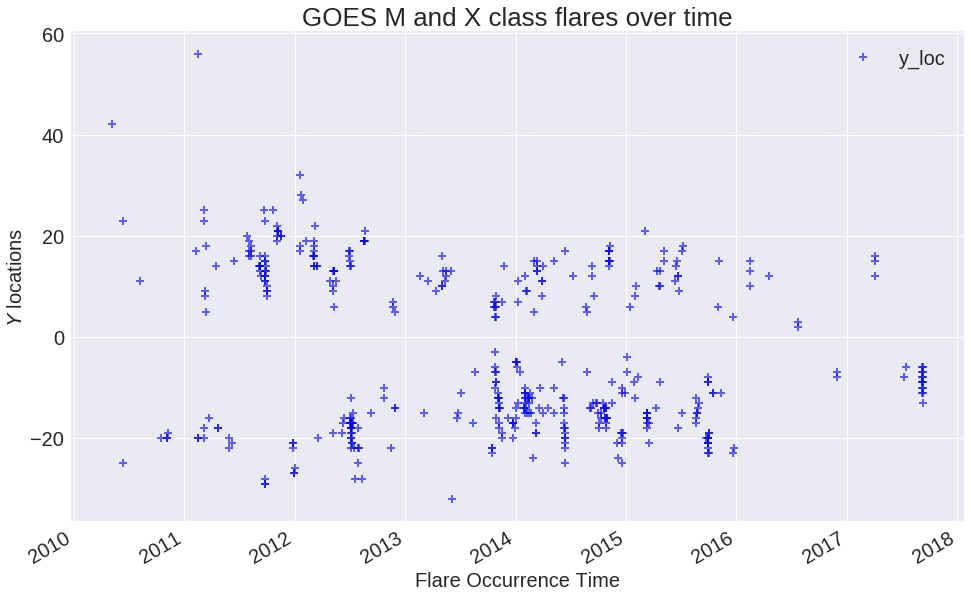

In [213]:


_plotter = all_goes.copy()

_plotter_2011 = _plotter#[ _plotter['Year'] == '2011' ]
_plotter_2011['class'] = _plotter_2011['goes_class'].str[:1] 
_plotter_2011 = _plotter_2011[_plotter_2011['class'] > 'C']

_plotter_2011 = _plotter_2011[_plotter_2011['goes_location'] != '(0, 0)']
_plotter_2011['x_loc'] = _plotter_2011['goes_location'].str.strip(')').str.strip('(').str.split(', ').apply(lambda x: x[0])
_plotter_2011['y_loc'] = _plotter_2011['goes_location'].str.strip(')').str.strip('(').str.split(', ').apply(lambda x: x[1])


x_loc = pd.to_numeric(_plotter_2011['x_loc'])
y_loc = pd.to_numeric(_plotter_2011['y_loc'])
_plotter_2011['x_loc'] = x_loc
_plotter_2011['y_loc'] = y_loc
print _plotter_2011.shape[0]
_plotter_2011.head()

plt.rcParams["figure.figsize"] = (16,10)
plt.rcParams.update({'font.size': 20})
plt.rc('xtick', labelsize=20)
plt.rc('ytick', labelsize=20)
params = {'legend.fontsize': 20,
          'legend.handlelength': 2}
plt.rcParams.update(params)
# fig = plt.figure()
ax = _plotter_2011.plot(x='peak_time', y='y_loc', style="P", markersize=8, c='b', alpha=0.6)
ax.set_ylabel("$Y$ locations")
ax.set_xlabel("Flare Occurrence Time")
mytitle = "GOES M and X class flares over time" 
ax.set_title(mytitle)
fig = ax.get_figure()
fig.savefig(mytitle + '.pdf',  bbox_inches='tight', dpi=fig.dpi)

/home/baydin2/anaconda2/lib/python2.7/site-packages/ipykernel/__main__.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy
/home/baydin2/anaconda2/lib/python2.7/site-packages/ipykernel/__main__.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy
/home/baydin2/anaconda2/lib/python2.7/site-packages/ipykernel/__main__.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/

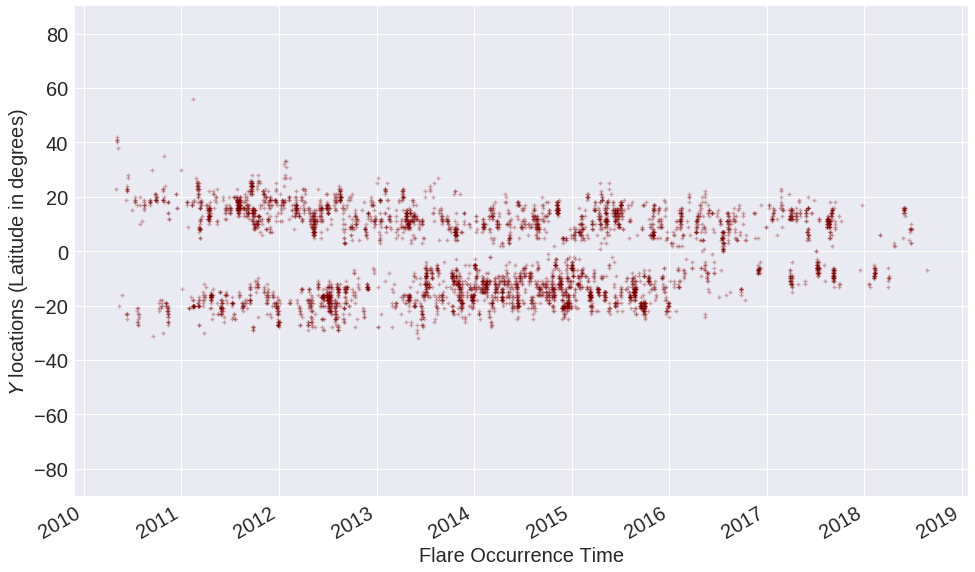

In [30]:


_plotter = all_goes.copy()

_plotter['Day'] = _plotter['event_date'].str[8:10] 
_plotter['Month'] = _plotter['event_date'].str[5:7] 
_plotter['Year'] = _plotter['event_date'].str[:4] 
_plotter['Year-Month'] = _plotter[['Year','Month', 'Day']].apply(lambda x: '-'.join(x), axis=1)
_plotter.sort_values(['Year-Month'])

_plotter_2011 = _plotter#[ _plotter['Year'] == '2011' ]
_plotter_2011['class'] = _plotter_2011['goes_class'].str[:1] 
# _plotter_2011 = _plotter_2011[_plotter_2011['class'] == 'C']

_plotter_2011 = _plotter_2011[_plotter_2011['goes_location'] != '(0, 0)']
_plotter_2011['x_loc'] = _plotter_2011['goes_location'].str.strip(')').str.strip('(').str.split(', ').apply(lambda x: x[0])
_plotter_2011['y_loc'] = _plotter_2011['goes_location'].str.strip(')').str.strip('(').str.split(', ').apply(lambda x: x[1])

# _plotter_2011[_plotter_2011['y_loc'] < -70]

x_loc = pd.to_numeric(_plotter_2011['x_loc'])
y_loc = pd.to_numeric(_plotter_2011['y_loc'])
_plotter_2011['x_loc'] = x_loc
_plotter_2011['y_loc'] = y_loc


plt.rcParams["figure.figsize"] = (16,10)
plt.rcParams.update({'font.size': 20})
plt.rc('xtick', labelsize=20)
plt.rc('ytick', labelsize=20)
params = {'legend.fontsize': 20,
          'legend.handlelength': 2}
plt.rcParams.update(params)
# fig = plt.figure()
ax = _plotter_2011.plot(x='peak_time', y='y_loc', style="P", markersize=4, alpha=0.33, c='maroon')
ax.set_ylabel("$Y$ locations (Latitude in degrees)")
ax.set_ylim(-90, 90)     # set the ylim to bottom, top
ax.legend_.remove()

ax.set_xlabel("Flare Occurrence Time")
mytitle = "GOES flares over time" 
# ax.set_title(mytitle)
fig = ax.get_figure()
fig.savefig(mytitle + '.pdf',  bbox_inches='tight', dpi=fig.dpi)


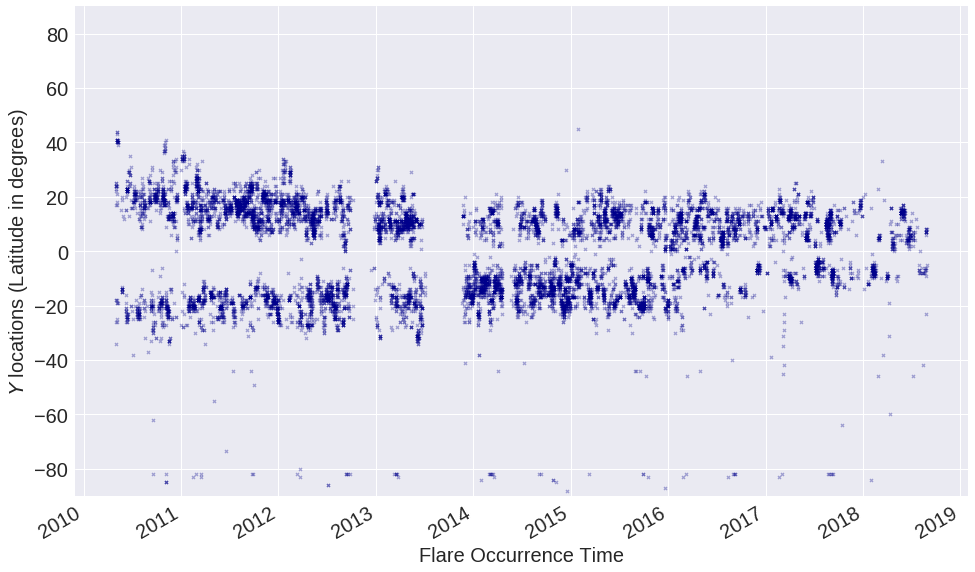

In [31]:

all_aia = get_aia_flare_dataframe('../datain/aia_flares_all.csv')

_plotter = all_aia.copy()
_plotter.head()

_plotter['Day'] = _plotter['event_date'].str[8:10] 
_plotter['Month'] = _plotter['event_date'].str[5:7] 
_plotter['Year'] = _plotter['event_date'].str[:4] 
_plotter['Year-Month'] = _plotter[['Year','Month', 'Day']].apply(lambda x: '-'.join(x), axis=1)
_plotter.sort_values(['Year-Month'])

_plotter_2011 = _plotter #[ _plotter['Year'] == '2011' ]
_plotter_2011['class'] = _plotter_2011['goes_class'].str[:1] 
# _plotter_2011 = _plotter_2011[_plotter_2011['class'] == 'C']


_plotter_2011['x_loc'] = _plotter_2011['goes_location'].str.strip(')').str.strip('POINT(').str.split(' ').apply(lambda x: x[0])
_plotter_2011['y_loc'] = _plotter_2011['goes_location'].str.strip(')').str.strip('POINT(').str.split(' ').apply(lambda x: x[1])


x_loc = pd.to_numeric(_plotter_2011['x_loc'])
y_loc = pd.to_numeric(_plotter_2011['y_loc'])
_plotter_2011['x_loc'] = x_loc
_plotter_2011['y_loc'] = y_loc


plt.rcParams["figure.figsize"] = (16,10)
plt.rcParams.update({'font.size': 20})
plt.rc('xtick', labelsize=20)
plt.rc('ytick', labelsize=20)
params = {'legend.fontsize': 20,
          'legend.handlelength': 2}
plt.rcParams.update(params)
# fig = plt.figure()
ax = _plotter_2011.plot(x='peak_time', y='y_loc', style="X", markersize=4, alpha=0.33, c='darkblue')
ax.set_ylabel("$Y$ locations (Latitude in degrees)")
ax.set_ylim(-90, 90)     # set the ylim to bottom, top
ax.legend_.remove()

ax.set_xlabel("Flare Occurrence Time")
mytitle = "AIA flares over time" 
# ax.set_title(mytitle)
fig = ax.get_figure()
fig.savefig(mytitle + '.pdf',  bbox_inches='tight', dpi=fig.dpi)


class  AR Info
B      False      1375
       True       4446
C      False       915
       True       6839
M      False        33
       True        759
dtype: int64
[[0.46874279 0.77508651 0.47412534 1.        ]
 [0.43529412 0.69096501 0.842599   1.        ]
 [0.89019608 0.18562092 0.15294118 1.        ]]
(0.0, 0.0, 0.2)


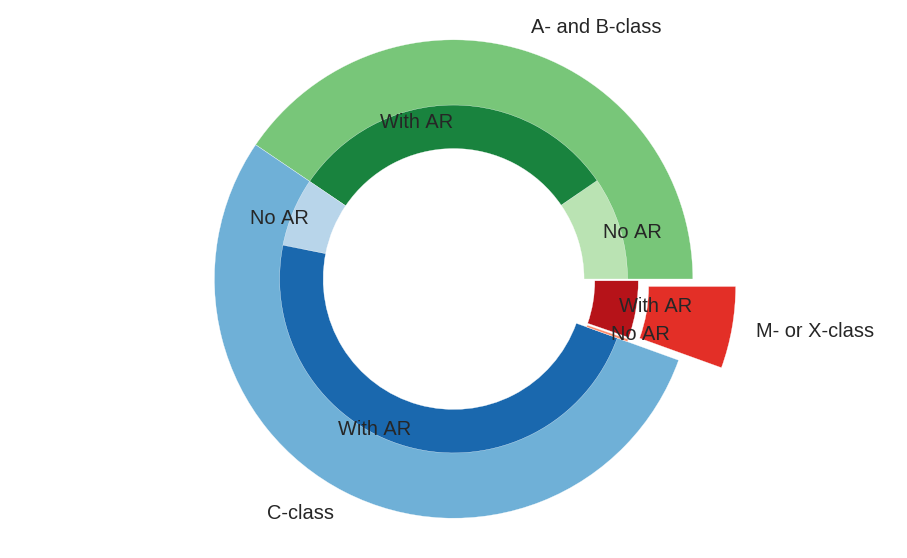

In [339]:
import numpy as np

all_goes = get_goes_flare_dataframe('../datain/goes_flares_all.csv')

_plotter = all_goes.copy()

_plotter['class'] = _plotter['goes_class'].str[:1]
mask = _plotter['class'] == 'A'
_plotter['class'] = _plotter['class'].where(~mask, other='B')
mask = _plotter['class'] == 'X'
_plotter['class'] = _plotter['class'].where(~mask, other='M')



_plotter['CoordInfo'] = _plotter['goes_location'] == '(0, 0)'
_plotter['AR Info'] =_plotter['noaa_active_region'] != 0
innermost = _plotter.groupby(['class', 'AR Info', 'CoordInfo']).size().values
print  _plotter.groupby(['class', 'AR Info']).size()
mid = _plotter.groupby(['class', 'AR Info']).size().values
outer = _plotter.groupby(['class']).size().values


fig, ax = plt.subplots()
ax.axis('equal')
width = 0.2

cm = plt.get_cmap("Greens")
cm2 = plt.get_cmap("Blues")
cm3 = plt.get_cmap("Reds")

cout = np.array([cm(np.arange(250))[125], cm2(np.arange(250) )[125],  cm3(np.arange(250))[170]] )
print cout
outer_labels = ['A- and B-class', 'C-class', 'M- or X-class']
exploder = (0.0, 0.0, 0.2)# tuple(100.0 / outer)
print exploder
pie, _ = ax.pie(outer, radius=1.1, labels=outer_labels, colors=cout, explode=exploder)

plt.setp( pie, width=width*2, edgecolor='white')

cin = np.array([cm(np.arange(250))[75],
                cm(np.arange(250))[200],
                cm2(np.arange(250))[75],
                cm2(np.arange(250))[200],
                cm3(np.arange(250))[100],
                cm3(np.arange(250))[209] ])
# print cin

labels = ['No AR', 'With AR'] * 3
exploder = (0.000, 0.0, 0.00, 0.0, 0.05, 0.05)
pie2, _ = ax.pie(mid, radius=1-width, labels=labels, explode=exploder,
                                       labeldistance=0.9,  colors=cin)
plt.setp( pie2, width=width, edgecolor='white')


# cin = np.array([cm(np.arange(250))[50],
#                 cm(np.arange(250))[75],
#                 cm(np.arange(250))[175],
#                 cm(np.arange(250))[200],
#                 cm2(np.arange(250))[80],
#                 cm2(np.arange(250))[120],
#                 cm2(np.arange(250))[150],
#                 cm2(np.arange(250))[200],
#                 cm3(np.arange(250))[170],
#                 cm3(np.arange(250))[100],
#                 cm3(np.arange(250))[80],
#                 cm3(np.arange(250))[50]])
# print len(innermost)
# exploder = (0.07, 0.07, 0.07, 0.07, 0.1, 0.1, 0.1, 0.1, 0.2, 0.2, 0.2)

# pie3, _ = ax.pie(innermost, radius=1-2*width, explode = exploder, #labels=labels,
#                                       labeldistance=0.7, colors=cin)
# plt.setp( pie3, width=width, edgecolor='white')

# plt.show()
plt.savefig('fl_loc_distribution.pdf', bbox_inches='tight')

class  AR Info  CoordInfo
M      False    True          33
       True     False        433
                True         326
dtype: int64
[ 33 433 326] [ 33 759]


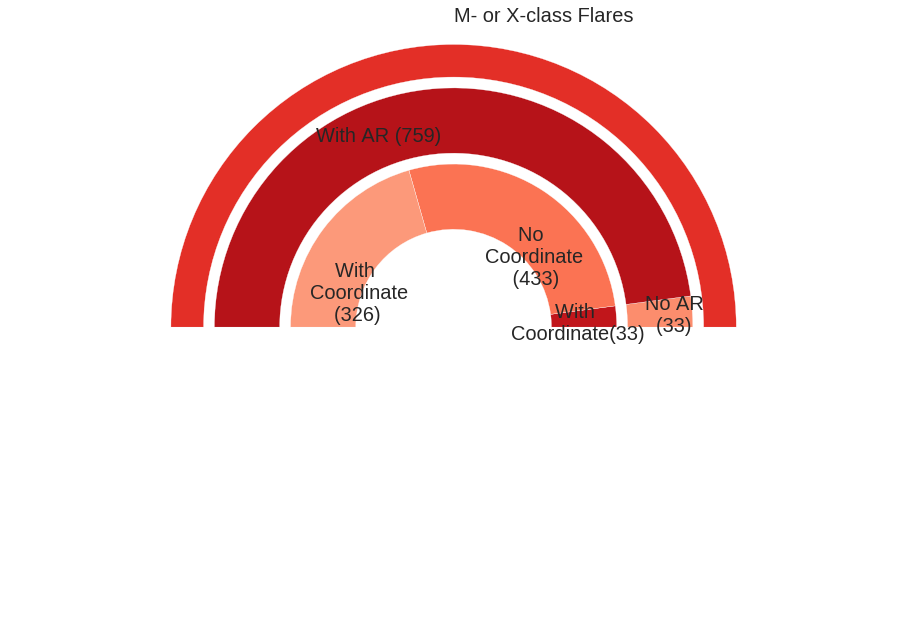

In [338]:
startangle=90

import numpy as np

all_goes = get_goes_flare_dataframe('../datain/goes_flares_all.csv')

_plotter = all_goes.copy()

_plotter['class'] = _plotter['goes_class'].str[:1]


mask = _plotter['class'] == 'A'
_plotter['class'] = _plotter['class'].where(~mask, other='B')
mask = _plotter['class'] == 'X'
_plotter['class'] = _plotter['class'].where(~mask, other='M')
_plotter = _plotter[_plotter['class'] == 'M']


_plotter['CoordInfo'] = _plotter['goes_location'] == '(0, 0)'
_plotter['AR Info'] =_plotter['noaa_active_region'] != 0
innermost = _plotter.groupby(['class', 'AR Info', 'CoordInfo']).size().values

print  _plotter.groupby(['class', 'AR Info', 'CoordInfo']).size()
mid = _plotter.groupby(['class', 'AR Info']).size().values
print innermost, mid

fig, ax = plt.subplots()
ax.axis('equal')
width = 0.3

cm = plt.get_cmap("Greens")
cm2 = plt.get_cmap("Blues")
cm3 = plt.get_cmap("Reds")

cout = np.array([cm3(np.arange(250))[170], [1,1,1,1]] )
outer_labels = ['M- or X-class Flares', '']
pie, _ = ax.pie(np.array([mid.sum(), mid.sum()]), radius=1.3, labels=outer_labels, startangle = 0, colors=cout)

plt.setp( pie, width=width/2.0, edgecolor='white')

mid_labels = ['No AR\n  (33)', 'With AR (759)', ''] 
cmid = np.array([cm3(np.arange(250))[100], cm3(np.arange(250))[209], [1,1,1,1]] )
pie, _ = ax.pie(np.append(mid, [mid.sum()]), radius=1.1, labels=mid_labels, labeldistance=0.8, 
                startangle = 0, colors=cmid)
plt.setp( pie, width=width, edgecolor='white')

inner_labels = ['        With\nCoordinate(33)', '      No\nCoordinate\n     (433)\n\n', 'With      \nCoordinate\n(326)     ', ''] 
cin = np.array([cm3(np.arange(250))[200], cm3(np.arange(250))[120], cm3(np.arange(250))[90], [1,1,1,1]] )

pien, _ = ax.pie(np.append(innermost, [mid.sum()]), radius=1.05-width, labels=inner_labels, 
                labeldistance=0.35, startangle = 0, colors=cin)
plt.setp( pien, width=width, edgecolor='white')


plt.savefig('M-X distribution.pdf', bbox_inches='tight')

class  AR Info  CoordInfo
C      False    False          31
                True          884
       True     False        3382
                True         3457
dtype: int64
[  31  884 3382 3457] [ 915 6839]


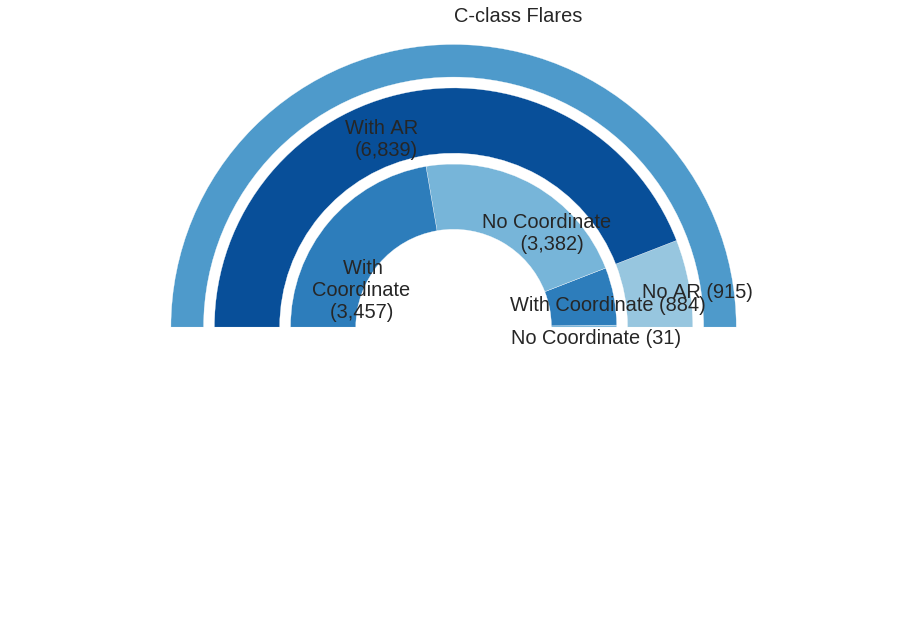

In [337]:
startangle=90

import numpy as np

all_goes = get_goes_flare_dataframe('../datain/goes_flares_all.csv')

_plotter = all_goes.copy()

_plotter['class'] = _plotter['goes_class'].str[:1]


mask = _plotter['class'] == 'A'
_plotter['class'] = _plotter['class'].where(~mask, other='B')
mask = _plotter['class'] == 'X'
_plotter['class'] = _plotter['class'].where(~mask, other='M')
_plotter = _plotter[_plotter['class'] == 'C']


_plotter['CoordInfo'] = _plotter['goes_location'] == '(0, 0)'
_plotter['AR Info'] =_plotter['noaa_active_region'] != 0
innermost = _plotter.groupby(['class', 'AR Info', 'CoordInfo']).size().values

print  _plotter.groupby(['class', 'AR Info', 'CoordInfo']).size()
mid = _plotter.groupby(['class', 'AR Info']).size().values
print innermost, mid

fig, ax = plt.subplots()
ax.axis('equal')
width = 0.3

# cm = plt.get_cmap("Greens")
cm3 = plt.get_cmap("Blues")
# cm3 = plt.get_cmap("Reds")

cout = np.array([cm3(np.arange(250))[150], [1,1,1,1]] )
outer_labels = ['C-class Flares', '']
pie, _ = ax.pie(np.array([mid.sum(), mid.sum()]), radius=1.3, labels=outer_labels, startangle = 0, colors=cout)

plt.setp( pie, width=width/2.0, edgecolor='white')

mid_labels = ['No AR (915)', 'With AR\n(6,839)', ''] 
cmid = np.array([cm3(np.arange(250))[100], cm3(np.arange(250))[225], [1,1,1,1]] )
pie, _ = ax.pie(np.append(mid, [mid.sum()]), radius=1.1, labels=mid_labels, labeldistance=0.8, 
                startangle = 0, colors=cmid)
plt.setp( pie, width=width, edgecolor='white')

inner_labels = ['\nNo Coordinate (31)', 'With Coordinate (884)\n', 'No Coordinate\n       (3,382)\n\n\n\n', 
                'With     \nCoordinate\n(3,457)   ', ''] 
cin = np.array([cm3(np.arange(250))[120], cm3(np.arange(250))[180], cm3(np.arange(250))[120], cm3(np.arange(250))[180], [1,1,1,1]] )

pien, _ = ax.pie(np.append(innermost, [mid.sum()]), radius=1.05-width, labels=inner_labels, 
                labeldistance=0.35, startangle = 0, colors=cin)
plt.setp( pien, width=width, edgecolor='white')


plt.savefig('C distribution.pdf', bbox_inches='tight')